Importing py libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from collections import Counter
from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

SEED + Motifs

In [25]:
SEED = 42
random.seed(SEED)

ARG_MOTIFS = [
    "ATGAGTATTCAACATTTCCGTGTCGCCC",
    "GCTATGCGTCAGCAAGACATTTGCCCAG",
    "ATGCGTTATATTCGCCTGTGTATCCCCT",
    "TTTCTTTACCAGAAACGCTGGTGAAAGT",
    "ACGCTGAAGAATGAAATGGTGAGCGAGA"
]

NON_ARG_MOTIFS = [
    "ATGGATATTCGCAAAGTAAAAGTTGTTCC",
    "ATGCGAGTGTTGAAGTTCGGCGGTACAT",
    "ATGGTTAAAGTTTATGCCCCGGCTTCCA",
    "ATGCGTGTTGAAATCGAAGGTAAAACGG",
    "ATGAAAATCGAAGAAGGTAAACTGGTAA"
]

rand_dna function


In [26]:
def rand_dna(length):
    return "".join(random.choices("ATGC", k=length))

making seq function

In [27]:
def make_seq(motif_list, L=500):

    motif = random.choice(motif_list)

    left = random.randint(0, L - len(motif))

    right = L - len(motif) - left

    sequence = rand_dna(left) + motif + rand_dna(right)

    return sequence

In [28]:
records = []

# ARG sequences
for _ in range(10000):
    records.append((make_seq(ARG_MOTIFS), 1))

# NON ARG sequences
for _ in range(10000):
    records.append((make_seq(NON_ARG_MOTIFS), 0))

df = pd.DataFrame(records, columns=["sequence", "label"])

In [29]:
records = []

# ARG sequences
for _ in range(10000):
    records.append((make_seq(ARG_MOTIFS), 1))

# NON ARG sequences
for _ in range(10000):
    records.append((make_seq(NON_ARG_MOTIFS), 0))

df = pd.DataFrame(records, columns=["sequence", "label"])

In [30]:
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

df.head()

,sequence,label
0,TTCACTCGCTAGGCTCACTCACTGTCATAAAAGAGCACTTTACAAC...,0
1,TACAGATCGCTCTAGCGAAGGGGCGAGAGTCGGTACGAAAGTAGCC...,1
2,ATTGACGTTTAATATCATCTTAAGTTCCGCGATGAGCCATTCCGCC...,1
3,TCGATCGGTGATTTGTTACGCCGCACGGAAAACAAATGTGTGAACG...,1
4,CATGAAAATCGAAGAAGGTAAACTGGTAATTTGCATTCGATTGTCA...,0


In [31]:
len(df)

20000

In [32]:
print(df.shape)

(20000, 2)


In [33]:
df["label"].value_counts()

,count
label,
0,10000
1,10000


In [34]:
df["sequence"].iloc[0]

'TTCACTCGCTAGGCTCACTCACTGTCATAAAAGAGCACTTTACAACCCCATTGTCTCGGAGCCTCCTTTTGATCCCTTCTATCGCAGGTAGCAACACTCTGACACTGAACAGGGAGATCAACATCTCTGTAATGTCATGTAGTGGCGTTCAGTTGTTATATCACGCCACATCCCGTTCCAGCAATGTTGGGGTTATCCGCCGACCCCAAGTGTCCAGCTACACAGGACTAACTGCAGCTTCATAGGTCCACACATCTCGCTATGTAATGTCTCGATGCGCATTGTTTGTTCACCCCGTGGCGTTAAGAACAGTGTCGCATGTAGCCGGCACCCAATTAAAAACAACCCTAATGAAAATCGAAGAAGGTAAACTGGTAACTGGTTGGTAGTCAAGAGCAAGACTACAAAACCTTCGGCGCAGACTTACCCATTTTATTACATCGTGGGCTTTAGTCTTGCCTACCTCACAGACAGTAACAAAGATATATGCATCAACGATA'

In [35]:
X = df["sequence"]
y = df["label"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

print(len(X_train))
print(len(X_test))

16000
4000


In [37]:
k = 3

K_MERS = [
    "".join(p)
    for p in product("ATGC", repeat=k)
]

print(K_MERS[:10])

['AAA', 'AAT', 'AAG', 'AAC', 'ATA', 'ATT', 'ATG', 'ATC', 'AGA', 'AGT']


In [38]:
def freq_vector(seq, k=3):

    counts = Counter(
        seq[i:i+k]
        for i in range(len(seq) - k + 1)
    )

    vec = np.array(
        [counts.get(km, 0) for km in K_MERS],
        dtype=float
    )

    total = vec.sum()

    if total > 0:
        vec = vec / total

    return vec

In [39]:
X_train = np.array([
    freq_vector(seq)
    for seq in X_train
])

X_test = np.array([
    freq_vector(seq)
    for seq in X_test
])

print(X_train.shape)

(16000, 64)


In [40]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
accuracy = rf.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.70875


In [42]:
from sklearn.metrics import f1_score, classification_report

y_pred_rf1 = rf.predict(X_test)
print("RF F1 Score (Sequence only):", f1_score(y_test, y_pred_rf1))

RF F1 Score (Sequence only): 0.7046894803548795


In [43]:


lr1 = LogisticRegression(random_state=SEED)
lr1.fit(X_train, y_train)
print("LR Accuracy:", lr1.score(X_test, y_test))

y_pred_lr1 = lr1.predict(X_test)
print("LR F1 Score (Sequence only):", f1_score(y_test, y_pred_lr1))

LR Accuracy: 0.69775
LR F1 Score (Sequence only): 0.6943109987357775


In [44]:
prediction = rf.predict(X_test[:5])

print(prediction)

[1 0 1 0 0]


In [45]:
print(y_test.iloc[:5].values)

[1 0 1 0 0]


In [46]:
def get_gc_content(seq):
    return (seq.count("G") + seq.count("C")) / len(seq)

df["gc_content"] = df["sequence"].apply(get_gc_content)
df.head()

,sequence,label,gc_content
0,TTCACTCGCTAGGCTCACTCACTGTCATAAAAGAGCACTTTACAAC...,0,0.464
1,TACAGATCGCTCTAGCGAAGGGGCGAGAGTCGGTACGAAAGTAGCC...,1,0.486
2,ATTGACGTTTAATATCATCTTAAGTTCCGCGATGAGCCATTCCGCC...,1,0.530
3,TCGATCGGTGATTTGTTACGCCGCACGGAAAACAAATGTGTGAACG...,1,0.470
4,CATGAAAATCGAAGAAGGTAAACTGGTAATTTGCATTCGATTGTCA...,0,0.494


In [47]:
X2 = df[["sequence", "gc_content"]]
y2 = df["label"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=SEED)

X2_train = X2_train.copy()
X2_test  = X2_test.copy()

X2_train["sequence"] = [np.array(freq_vector(seq)) for seq in X2_train["sequence"]]
X2_test["sequence"]  = [np.array(freq_vector(seq)) for seq in X2_test["sequence"]]

X2_train_seq = np.stack(X2_train["sequence"].values)
X2_test_seq  = np.stack(X2_test["sequence"].values)

X2_train_gc = X2_train["gc_content"].values.reshape(-1, 1)
X2_test_gc  = X2_test["gc_content"].values.reshape(-1, 1)

X2_train_processed = np.concatenate([X2_train_seq, X2_train_gc], axis=1)
X2_test_processed  = np.concatenate([X2_test_seq,  X2_test_gc],  axis=1)

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf2 = RandomForestClassifier(random_state=SEED)
rf2.fit(X2_train_processed, y2_train)
print("RF Accuracy (Seq + GC):", rf2.score(X2_test_processed, y2_test))

lr2 = LogisticRegression(random_state=SEED)
lr2.fit(X2_train_processed, y2_train)
print("LR Accuracy (Seq + GC):", lr2.score(X2_test_processed, y2_test))

RF Accuracy (Seq + GC): 0.70325
LR Accuracy (Seq + GC): 0.694


In [49]:
y_pred_rf2 = rf2.predict(X2_test_processed)
print("RF F1 Score (Seq + GC):", f1_score(y2_test, y_pred_rf2))

y_pred_lr2 = lr2.predict(X2_test_processed)
print("LR F1 Score (Seq + GC):", f1_score(y2_test, y_pred_lr2))

RF F1 Score (Seq + GC): 0.7019834295756967
LR F1 Score (Seq + GC): 0.6909090909090909


i just use this to illustrate

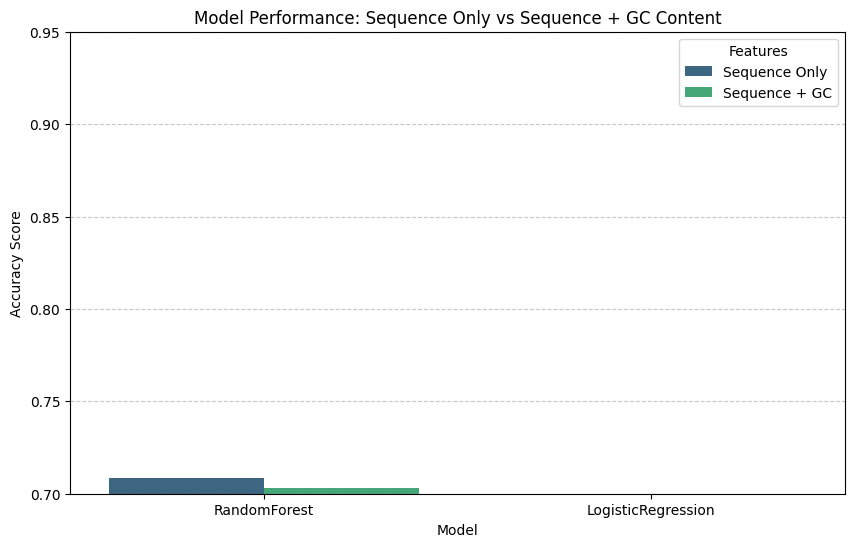

In [50]:
import seaborn as sns

performance_data = {
    "Model": ["RandomForest", "RandomForest", "LogisticRegression", "LogisticRegression"],
    "Features": ["Sequence Only", "Sequence + GC", "Sequence Only", "Sequence + GC"],
    "Score": [
        rf.score(X_test, y_test),
        rf2.score(X2_test_processed, y2_test),
        lr1.score(X_test, y_test),
        lr2.score(X2_test_processed, y2_test)
    ]
}

performance_df = pd.DataFrame(performance_data)

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Score", hue="Features", data=performance_df, palette="viridis")
plt.title("Model Performance: Sequence Only vs Sequence + GC Content")
plt.ylabel("Accuracy Score")
plt.ylim(0.7, 0.95)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()